<a href="https://colab.research.google.com/github/sevaradevoloper/mldanishla/blob/main/SpotifyTracks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!pip install legacy-cgi

In [54]:
# 🎹 Spotify Tracks Dataset

In [55]:
import opendatasets as od

In [56]:
od.download("https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset")

Skipping, found downloaded files in "./-spotify-tracks-dataset" (use force=True to force download)


In [57]:
!kaggle datasets download -d maharshipandya/spotify-tracks-dataset

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [108]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import lightgbm as lgb
from lightgbm  import LGBMRegressor

from sklearn.metrics import root_mean_squared_error

from sklearn.model_selection import GridSearchCV

In [59]:
df = pd.read_csv("/content/-spotify-tracks-dataset/dataset.csv")
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [60]:
df.shape

(114000, 21)

In [61]:
print(df.isnull().sum())
print(df.duplicated().sum())

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64
0


In [62]:
df.columns.tolist()

['Unnamed: 0',
 'track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

In [63]:
# Preprocessing:

In [66]:
drop_cols = ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name']
df_clean = df.drop(columns=drop_cols)
df["track_genre"] = df["track_genre"].astype("category")
df_clean.info()
df["track_genre"].dtype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   popularity        114000 non-null  int64   
 1   duration_ms       114000 non-null  int64   
 2   explicit          114000 non-null  bool    
 3   danceability      114000 non-null  float64 
 4   energy            114000 non-null  float64 
 5   key               114000 non-null  int64   
 6   loudness          114000 non-null  float64 
 7   mode              114000 non-null  int64   
 8   speechiness       114000 non-null  float64 
 9   acousticness      114000 non-null  float64 
 10  instrumentalness  114000 non-null  float64 
 11  liveness          114000 non-null  float64 
 12  valence           114000 non-null  float64 
 13  tempo             114000 non-null  float64 
 14  time_signature    114000 non-null  int64   
 15  track_genre       114000 non-null  category
dtypes:

CategoricalDtype(categories=['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
                  'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
                  ...
                  'spanish', 'study', 'swedish', 'synth-pop', 'tango',
                  'techno', 'trance', 'trip-hop', 'turkish', 'world-music'],
, ordered=False, categories_dtype=object)

In [64]:
# y ustunimiz bu Popularity uni korib olamiz

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


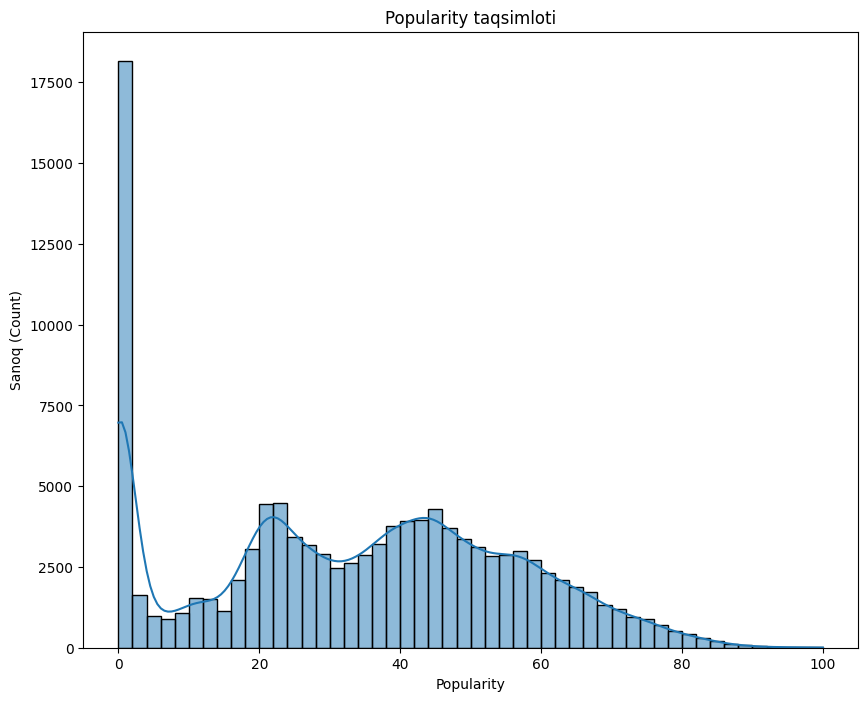

In [70]:
print(df_clean["popularity"].describe())

plt.figure(figsize=(10,8))
sns.histplot(data=df_clean['popularity'],bins=50,kde=True)
plt.title("Popularity taqsimloti")
plt.xlabel('Popularity')
plt.ylabel('Sanoq (Count)')
plt.show()

In [72]:
df_clean.columns.tolist()

['popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

In [ ]:
# X ya y ajratib olamiz:

In [76]:
X = df_clean.drop(columns=['popularity'])
y = df_clean['popularity']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)


(91200, 15)
(22800, 15)


In [81]:
# model uchun Parametrlarini sozlab olamiz
model = LGBMRegressor(
    objective = 'regression',
    n_estimators=1000,
    learning_rate = 0.05,
    num_leaves = 31,
    max_depth = -1,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 11,
    n_jobs = -1
)

In [84]:
# model Fit()

callbacks = [
    lgb.early_stopping(stopping_rounds=50),  # 50 ta tree davomida RMSE yaxshilanmasa to'xtaydi
    lgb.log_evaluation(period=100)           # Har 100-daraxtda natijani ekranga chiqaradi
]
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], # Train va Test xatoliklarini kuzatib boradi
    eval_names=['train', 'valid'],
    callbacks=callbacks
    )


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013561 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2685
[LightGBM] [Info] Number of data points in the train set: 91200, number of used features: 15
[LightGBM] [Info] Start training from score 33.281711
Training until validation scores don't improve for 50 rounds
[100]	train's l2: 325.102	valid's l2: 332.925
[200]	train's l2: 297.565	valid's l2: 315.894
[300]	train's l2: 279.277	valid's l2: 305.056
[400]	train's l2: 264.454	valid's l2: 297.32
[500]	train's l2: 251.967	valid's l2: 290.869
[600]	train's l2: 241.484	valid's l2: 285.703
[700]	train's l2: 232.105	valid's l2: 281.264
[800]	train's l2: 224.002	valid's l2: 277.958
[900]	train's l2: 216.59	valid's l2: 275.01
[1000]	train's l2: 209.284	valid's l2: 272.138
Did not meet early stopping. Best iteration is:
[1000]	train's l2: 209.284	valid's l2: 272.138


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              n_jobs=-1, objective='regression', random_state=11,
              subsample=0.8)

[100] va [1000]: Model qurgan daraxtlar soni (100-qadam va 1000-qadam).   


l2 (MSE - Kvadratik xatolik): Bu xatolik darajasi. Bu raqam qancha kichik bo'lsa, model shuncha aniq ishlayapti degani!



train's l2: Model o'zi tayyorgarlik ko'rayotgan kitobdagi xatoligi (325→209 ga tushib, xatosi kamaygan).   


valid's l2: Model imtihonda (testda) yo'l qo'yayotgan xatoligi (332→272 ga tushib, bu ham kamaygan).

In [86]:
# predict

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)


In [87]:
# rmse
train_rmse = root_mean_squared_error(y_train,train_pred)
test_rmse = root_mean_squared_error(y_test,test_pred)

print(f"\n=============================")
print(f"O'qitish to'xtagan eng yaxshi iteration: {model.best_iteration_}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")
print(f"=============================")


O'qitish to'xtagan eng yaxshi iteration: 1000
Train RMSE: 14.4667
Test RMSE:  16.4966


In [ ]:
# Feature Importance

In [90]:
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance':model.feature_importances_
}).sort_values('importance',ascending=False)

print(feature_importances)


             feature  importance
14       track_genre        4613
7        speechiness        2655
8       acousticness        2552
0        duration_ms        2487
5           loudness        2471
2       danceability        2452
11           valence        2385
3             energy        2367
12             tempo        2351
10          liveness        2312
9   instrumentalness        1883
4                key         905
6               mode         237
1           explicit         196
13    time_signature         134


track_genre (4613) — Qo'shiqning janri (pop, rock, jazz va h.k.). Eng muhim ustun! Model qo'shiqning mashhurligini aniqlashda 4613 marta aynan shu ustunga tayanib qaror qabul qilgan.   


speechiness (2655) — Qo'shiqda inson nutqi (gapirish/rep) qanchalik ko'pligi.   

acousticness (2552) — Qo'shiqning akustik (jonli cholg'ular) darajasi.   

duration_ms (2487) — Qo'shiqning davomiyligi (vaqti, millisekundlarda).   

loudness (2471) — Ovoz balandligi (desibellarda).   

danceability (2452) — Raqsga tushishbopligi (ritmi raqsga nechoqlik mosligi).   

valence (2385) — Qo'shiqning kayfiyati (quvnoq yoki g'amginligi).   

energy (2367) — Energiya va shijoat darajasi (tezlik va shovqinligi).   

tempo (2351) — Musiqa sur'ati (BPM — daqiqasiga zarbalar soni).   

liveness (2312) — Qo'shiq jonli konsertda yozib olinganlik ehtimoli.   

instrumentalness (1883) — So'zsiz, faqat musiqadan iboratlik darajasi.   

key (905) — Musiqiy kaliti (nota tonalligi).   

mode (237) — Lad turi (major/quvnoq yoki minor/g'amgin).   

explicit (196) — Uyatsiz/so'kish so'zlar bor-yo'qligi (1 — bor, 0 — yo'q).   

time_signature (134) — Musiqa o'lchovi (masalan, 4/4 yoki 3/4).   


/tmp/ipykernel_873/4122955188.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


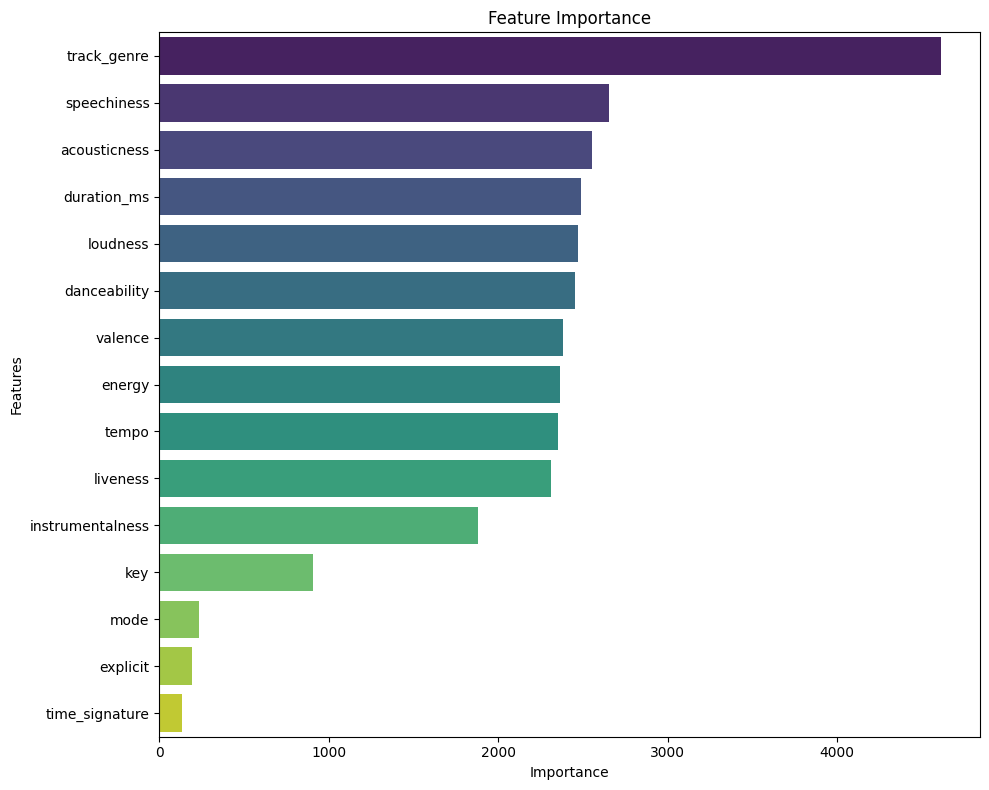

In [97]:
plt.figure(figsize=(10,8))
sns.barplot(
    data=feature_importances,
    x='importance',
    y='feature',
    palette = 'viridis'
    )
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [104]:
num_leaves = [8, 31, 100,200,300]

train_rmse_list = []
test_rmse_list = []

for o in num_leaves:
    model = LGBMRegressor(
        objective='regression',
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=o,            # Sikldagi 'o' qiymatini beramiz
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=11,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, train_pred)
    test_rmse = root_mean_squared_error(y_test, test_pred)

    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)

    print(f"num_leaves: {o:3d} | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

num_leaves:   8 | Train RMSE: 17.1608 | Test RMSE: 17.7182
num_leaves:  31 | Train RMSE: 14.4667 | Test RMSE: 16.4966
num_leaves: 100 | Train RMSE: 10.8453 | Test RMSE: 15.5216
num_leaves: 200 | Train RMSE: 8.2670 | Test RMSE: 15.0580
num_leaves: 300 | Train RMSE: 6.8913 | Test RMSE: 14.8811


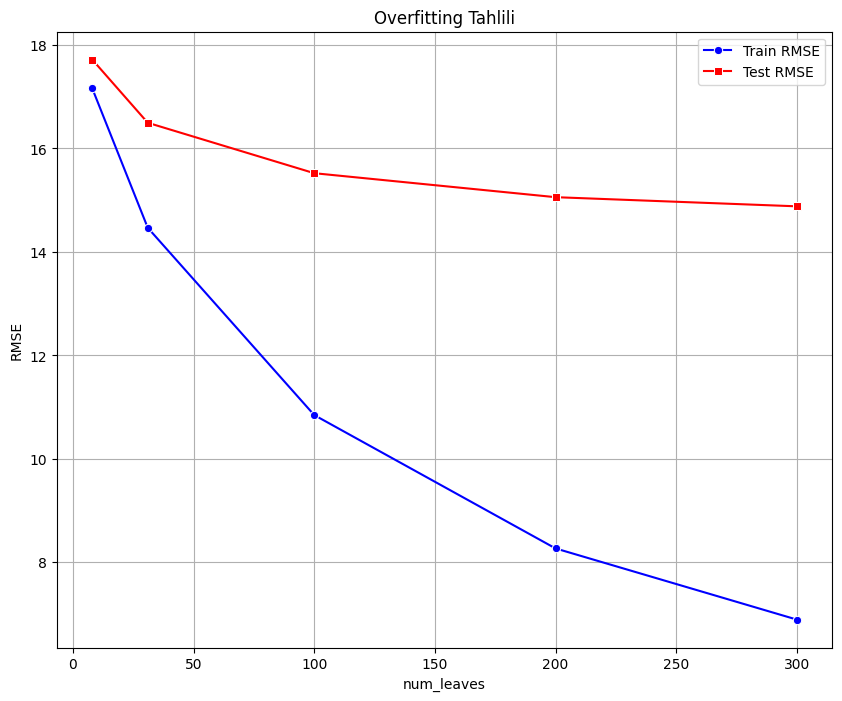

In [105]:
plt.figure(figsize=(10,8))
sns.lineplot(x=num_leaves, y=train_rmse_list, label='Train RMSE', marker='o', color='blue')
sns.lineplot(x=num_leaves, y=test_rmse_list, label='Test RMSE', marker='s', color='red')

plt.xlabel('num_leaves')
plt.ylabel('RMSE')
plt.title('Overfitting Tahlili')
plt.grid(True)
plt.show()

In [109]:
# max_depth = [-1,5,12,15]
# min_child_samples = [20, 50, 100]

# results = []

# for mx in max_depth:
#   for mcs in min_child_samples:
#     model = LGBMRegressor(
#         objective='regression',
#         n_estimators=1000,
#         learning_rate=0.05,
#         num_leaves=100,            # 100 eng yaxshisi chiqanligi uchun
#         max_depth= mx,
#         min_child_samples = mcs,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         random_state=11,
#         n_jobs=-1,
#         verbose=-1
#     )
#     model.fit(X_train, y_train)

#     train_pred = model.predict(X_train)
#     test_pred = model.predict(X_test)

#     train_rmse = root_mean_squared_error(y_train, train_pred)
#     test_rmse = root_mean_squared_error(y_test, test_pred)

#     results.append({
#         'max_depth':mx,
#         'min_child_samples':mcs,
#         'train_rmse':train_rmse,
#         'test_rmse':test_rmse
#     })

#     print(f"max_depth: {mx:2d}  min_child_samples: {mcs:3d} | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

# df_results = pd.DataFrame(results)

In [112]:
# GridSearchCV

params_grid = {
    'num_leaves': [100],                       # Biz topgan optimal barglar soni
    'max_depth': [-1, 5, 12, 15],              # Siz tanlagan max_depth ro'yxati
    'min_child_samples': [20, 50, 100],        # Siz tanlagan min_child_samples ro'yxati
    'learning_rate': [0.05],
    'n_estimators': [1000],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# model_params
lgb_base = LGBMRegressor(
    objective='regression',
    random_state=11,
    n_jobs=-1,
    verbose=-1
)

# grCV
grid_search = GridSearchCV(
    estimator=lgb_base,
    param_grid=params_grid,
    scoring='neg_root_mean_squared_error',     # RMSE boyicha baholash
    cv=5,                                      # Ma'lumotlarni 5 ta qismga bo'lib cross-validation qilish
    verbose=1,
    n_jobs=-1
)

print("GridSearchCV jarayoni boshlandi (5-fold CV)...")
grid_search.fit(X_train,y_train)

print("======"*20)
print("GridSearchCV natijasi")
print(f"Eng yaxshi parametrlar: {grid_search.best_params_}")
print(f"Eng yaxshi CV RMSE: {-grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

test_gcv_pred = best_model.predict(X_test)
test_rmse_score = root_mean_squared_error(y_test,test_gcv_pred)

print(f"Test RMSE (Eng yaxshi model bilan): {test_rmse_score:.4f}")
print("="*40)

GridSearchCV jarayoni boshlandi (5-fold CV)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV natijasi
Eng yaxshi parametrlar: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 1000, 'num_leaves': 100, 'subsample': 0.8}
Eng yaxshi CV RMSE: 15.8396
Test RMSE (Eng yaxshi model bilan): 15.5216


In [113]:
# time
import time

In [114]:
# XGBoost modeli
from xgboost import XGBRegressor

In [122]:
# ---------------------------------------------------------
# 0. XGBoost uchun ma'lumotlarni tayyorlash
# ---------------------------------------------------------
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

# Barcha 'category' yoki 'object' tipidagi ustunlarni raqamli kodlarga o'tkazamiz
for col in X_train_xgb.select_dtypes(include=['category', 'object']).columns:
    X_train_xgb[col] = X_train_xgb[col].astype('category').cat.codes
    X_test_xgb[col] = X_test_xgb[col].astype('category').cat.codes

# ---------------------------------------------------------
# 1. LightGBM (Best Model) ni o'qitish va vaqtni o'lchash
# ---------------------------------------------------------
lgbm_model = LGBMRegressor(
    objective='regression',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=11,
    n_jobs=-1,
    verbose=-1
)

start_time = time.perf_counter()
lgbm_model.fit(X_train, y_train)
lgbm_time = time.perf_counter() - start_time

lgbm_train_pred = lgbm_model.predict(X_train)
lgbm_test_pred = lgbm_model.predict(X_test)

lgbm_train_rmse = root_mean_squared_error(y_train, lgbm_train_pred)
lgbm_test_rmse = root_mean_squared_error(y_test, lgbm_test_pred)

print(f"LightGBM tayyor! Vaqt: {lgbm_time:.2f} s | Test RMSE: {lgbm_test_rmse:.4f}")

# ---------------------------------------------------------
# 2. XGBoost ni o'qitish va vaqtni o'lchash
# ---------------------------------------------------------
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,             # LGBM num_leaves=100 ga muqobil
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=11,
    n_jobs=-1,
    tree_method='hist'        # 's' harfisiz, to'g'ri nomi
)

start_time = time.perf_counter()
# fit qilishda ham X_train_xgb ishlatiladi!
xgb_model.fit(X_train_xgb, y_train)
xgb_time = time.perf_counter() - start_time

xgb_train_pred = xgb_model.predict(X_train_xgb)
xgb_test_pred = xgb_model.predict(X_test_xgb)

xgb_train_rmse = root_mean_squared_error(y_train, xgb_train_pred)
xgb_test_rmse = root_mean_squared_error(y_test, xgb_test_pred)

print(f"XGBoost tayyor! Vaqt: {xgb_time:.2f} s | Test RMSE: {xgb_test_rmse:.4f}")

# ---------------------------------------------------------
# 3. Solishtirish jadvalini tuzish
# ---------------------------------------------------------
comparison_df = pd.DataFrame([
    {
        'Model': 'LightGBM (best)',
        'Train RMSE': round(lgbm_train_rmse, 4),
        'Test RMSE': round(lgbm_test_rmse, 4),
        "O'qitilish vaqti (s)": round(lgbm_time, 2)
    },
    {
        'Model': 'XGBoost',
        'Train RMSE': round(xgb_train_rmse, 4),
        'Test RMSE': round(xgb_test_rmse, 4),
        "O'qitilish vaqti (s)": round(xgb_time, 2)
    }
])

print("\n" + "="*50)
print(comparison_df.to_string(index=False))
print("="*50)

LightGBM tayyor! Vaqt: 10.93 s | Test RMSE: 15.5216
XGBoost tayyor! Vaqt: 44.19 s | Test RMSE: 13.9235

          Model  Train RMSE  Test RMSE  O'qitilish vaqti (s)
LightGBM (best)     10.8453    15.5216                 10.93
        XGBoost      5.9295    13.9235                 44.19


In [123]:
comparison_df = pd.DataFrame([
    {
        'Model': 'LightGBM (best)',
        'Train RMSE': round(lgbm_train_rmse, 4),
        'Test RMSE': round(lgbm_test_rmse, 4),
        "O'qitilish vaqti (s)": round(lgbm_time, 2)
    },
    {
        'Model': 'XGBoost',
        'Train RMSE': round(xgb_train_rmse, 4),
        'Test RMSE': round(xgb_test_rmse, 4),
        "O'qitilish vaqti (s)": round(xgb_time, 2)
    }
])

print("\n" + "="*50)
print(comparison_df.to_string(index=False))
print("="*50)


          Model  Train RMSE  Test RMSE  O'qitilish vaqti (s)
LightGBM (best)     10.8453    15.5216                 10.93
        XGBoost      5.9295    13.9235                 44.19


XGBoost aniqroq: 13.92 vs 15.52, lekin 4x sekin va ko'proq overfit

Bu loyihada Spotify treklarining popularity'sini audio-xususiyatlar asosida bashorat qildim (regression). LightGBM va XGBoost'ni bir xil sozlamalar bilan solishtirganda, XGBoost Test RMSE bo'yicha yaxshiroq natija berdi (13.92 vs 15.52), lekin ... (tezlik/overfitting haqida). num_leaves tajribasi ko'rsatdiki ... (8 underfit, 100 eng past test lekin gap kengaydi). max_depth va min_child_samples bilan cheklash gap'ni kamaytirdi, ammo aniqlikni oshirmadi, demak bu datasetda ... . Yakuniy tanlangan parametrlar: ... . Umuman, popularity faqat audio-featurelardan to'liq bashorat qilinmaydi, chunki ... (artist mashhurligi, marketing yo'q).

In [124]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 20.5 MB/s eta 0:00:00


In [ ]:
import optuna
import lightgbm as lgb
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

# Optuna uchun maqsadli funksiya (Objective function)
def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'random_state': 11,
        'n_jobs': -1,
        'verbose': -1,
        'n_estimators': 1000,

        # Optuna qidiradigan giperparametrlar diapazoni:
        'num_leaves': trial.suggest_int('num_leaves', 31, 256),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }

    # Modelni o'qitish
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)

    # Test RMSE hisoblash
    preds = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, preds)
    return rmse

# Optuna study obyektini yaratamiz (RMSE'ni minimallashtirish uchun)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')

print("Optuna avtomatik tuning jarayoni boshlandi...")
study.optimize(objective, n_trials=30)  # 30 ta aqlli sinov o'tkaziladi

print("\n" + "="*50)
print("OPTUNA TUNING NATIJALARI:")
print("="*50)
print(f"Eng yaxshi Test RMSE: {study.best_value:.4f}")
print("Eng yaxshi giperparametrlar:")
for key, value in study.best_params_.items():
    print(f"  '{key}': {value}")
print("="*50)

In [126]:
!pip install gradio

In [ ]:
import gradio as gr
import pandas as pd

# 1. Model kutadigan barcha ustunlar ro'yxati
feature_names = list(X_train.columns)

def predict_popularity(*args):
    try:
        # Kiruvchi qiymatlardan DataFrame tuzamiz
        input_dict = {col: [val] for col, val in zip(feature_names, args)}
        input_df = pd.DataFrame(input_dict)

        # Categorical ustunlarni XGBoost mos formatga (cat.codes) o'tkazamiz
        for col in input_df.select_dtypes(include=['object', 'category']).columns:
            input_df[col] = input_df[col].astype('category').cat.codes

        # Model yordamida bashorat olamiz
        pred = xgb_model.predict(input_df)[0]

        # Qiymatni 0 va 100 oralig'ida chegaralaymiz
        final_score = max(0, min(100, round(float(pred), 2)))
        return f"🎵 Bashorat qilingan Popularity: {final_score} / 100"
    except Exception as e:
        return f"Xatolik yuz berdi: {str(e)}"

# 2. Barcha ustunlar uchun Gradio input interfeysini shakllantirish
inputs = []
for col in feature_names:
    if X_train[col].dtype in ['int64', 'float64', 'int32', 'float32']:
        default_val = float(X_train[col].mean())
        inputs.append(gr.Number(label=col, value=round(default_val, 2)))
    else:
        # Kategorik ustunlar uchun tekst kiritish
        inputs.append(gr.Textbox(label=col, value=str(X_train[col].iloc[0])))

# 3. Interfeysni ishga tushirish
demo = gr.Interface(
    fn=predict_popularity,
    inputs=inputs,
    outputs="text",
    title="🎧 Spotify Song Popularity Predictor",
    description="Qo'shiq xususiyatlarini kiriting va ML model (XGBoost) mashhurlikni bashorat qiladi."
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d7e707e390a82b4d5b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
